In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

sys.path.append(str(root_path))
params_path = root_path / "params/"

import json
import logging

import matplotlib.pyplot as plt
import numpy as np

from domain.distributions import SinhDistribution
from plotting.plot_style import plot_style
from src.mle_multiple_inits import mle_fit_multiple_inits
from utils.sampling.sampling_deadband import sample_sinh_distribution
from utils.seed import set_seed

In [2]:
# Force verbose logging in notebook

logging.basicConfig(level=logging.INFO, force=True)

In [3]:
# MLE constraints

with open(params_path / "mle_constraints.json", "r") as f:
    constraints = json.load(f)

constraints_sinh = {k: tuple(v) for k, v in constraints["constraints_sinh"].items()}

In [4]:
set_seed(123)

# Generate synthetic data with rejection sampling

In [5]:
true_a = 0.2
true_dist = SinhDistribution(true_a)
data = sample_sinh_distribution(true_dist, n=10000)

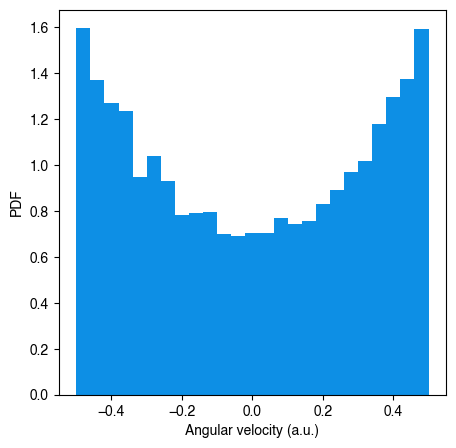

In [6]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data, bins=25, density=True)

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    plt.show()

# MLE fit

In [7]:
a_inits = [
    {"a": 0.1}
]  # to run with multiple inits pass [{"a": <val>}, {"a": <val>}, {"a": <val>}, ...]

result = mle_fit_multiple_inits(
    data=data,
    distribution="sinh",
    init_list=a_inits,
    constraints=constraints_sinh,
    max_iter=500,
    std_threshold=1,
    verbose=True,
)

INFO:root:Running initialization: 1/1: {'a': 0.1}
INFO:root:Starting MLE optimization for sinh distribution
INFO:root:Initial parameters: {'a': 0.1}
INFO:root:neg_log_likelihood=981.643782, delta_x=5.00e-03, delta_f=3.12e+02, params=[0.105]
INFO:root:neg_log_likelihood=726.057408, delta_x=5.00e-03, delta_f=2.56e+02, params=[0.11]
INFO:root:neg_log_likelihood=516.529610, delta_x=5.00e-03, delta_f=2.10e+02, params=[0.115]
INFO:root:neg_log_likelihood=203.739884, delta_x=1.00e-02, delta_f=3.13e+02, params=[0.125]
INFO:root:neg_log_likelihood=-6.379934, delta_x=1.00e-02, delta_f=2.10e+02, params=[0.135]
INFO:root:neg_log_likelihood=-239.051200, delta_x=2.00e-02, delta_f=2.33e+02, params=[0.155]
INFO:root:neg_log_likelihood=-334.862216, delta_x=2.00e-02, delta_f=9.58e+01, params=[0.175]
INFO:root:neg_log_likelihood=-363.409774, delta_x=4.00e-02, delta_f=2.85e+01, params=[0.215]
INFO:root:neg_log_likelihood=-324.914868, delta_x=4.00e-02, delta_f=3.85e+01, params=[0.255]
INFO:root:neg_log_lik

Optimization terminated successfully.
         Current function value: -366.896156
         Iterations: 27
         Function evaluations: 54


In [8]:
a_fit = result[0]["a"][0]
fitted_distribution = SinhDistribution(a=a_fit)

In [9]:
x_range = np.linspace(-fitted_distribution.omega_dz, fitted_distribution.omega_dz, 100)
pdf = fitted_distribution.pdf(x=x_range)

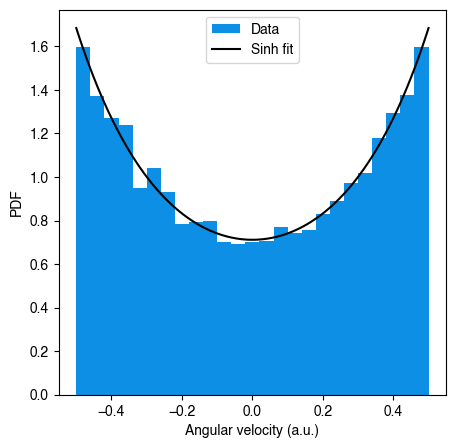

In [10]:
with plot_style():

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    ax.hist(data, bins=25, density=True, label="Data")
    ax.plot(x_range, pdf, color="black", lw=1.5, label="Sinh fit")

    ax.set_xlabel("Angular velocity (a.u.)")
    ax.set_ylabel("PDF")

    ax.legend(loc="upper center")

    plt.show()